# TriviaQA Dataset Exploration

TriviaQA reading comprehension dataset (~95K examples).  
Longer contexts with diverse trivia questions.  
HuggingFace: `trivia_qa`

In [1]:
%load_ext autoreload
%autoreload 2

In [9]:
import os
from pathlib import Path
from pprint import pprint
import re
import sys
from typing import Optional, List, Dict, Any, Tuple
if '..' not in sys.path: sys.path.append('..')

from datasets import load_dataset
from datasets.arrow_dataset import Dataset
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from transformers import AutoTokenizer, PreTrainedTokenizer

tkz = AutoTokenizer.from_pretrained('bert-base-uncased')
print(f'Tokenizer vocab size: {tkz.vocab_size}')

Tokenizer vocab size: 30522


In [3]:
DATA_PATH = Path('Q:/data')
QNA_DATA_PATH = DATA_PATH / 'qna'
QNA_DATA_PATH.mkdir(parents=True, exist_ok=True)

TRIVIAQA_HF_ID = 'trivia_qa'
TRIVIAQA_SUBSET = 'rc'  # 'rc' for reading comprehension subset with evidence documents
print(f'DATA_PATH: {DATA_PATH}')
print(f'TRIVIAQA_HF_ID: {TRIVIAQA_HF_ID} ({TRIVIAQA_SUBSET})')

DATA_PATH: Q:\data
TRIVIAQA_HF_ID: trivia_qa (rc)


## Load TriviaQA

In [4]:
# Load TriviaQA 'rc' (reading comprehension) subset — includes evidence documents
ds_tqa = load_dataset(TRIVIAQA_HF_ID, TRIVIAQA_SUBSET, cache_dir=str(DATA_PATH))
print(f'Splits: {list(ds_tqa.keys())}')
for split_name, split_ds in ds_tqa.items():
    print(f'  {split_name}: {len(split_ds)} examples')
print(f'\nFeatures: {list(ds_tqa["train"].features.keys())}')

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/138384 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/17944 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/17210 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/24 [00:00<?, ?it/s]

Splits: ['train', 'validation', 'test']
  train: 138384 examples
  validation: 17944 examples
  test: 17210 examples

Features: ['question', 'question_id', 'question_source', 'entity_pages', 'search_results', 'answer']


In [15]:
# Examine the structure of one example
ex = ds_tqa['train'][0]
print('Keys:', list(ex.keys()))
print()
print('Question:', ex['question'])
print('Question ID:', ex['question_id'])
print('Question source:', ex['question_source'])
print()

# Answer structure
print('Answer keys:', list(ex['answer'].keys()))
print('Answer value:', ex['answer']['value'])
print('Answer aliases:', ex['answer']['aliases'][:5] if len(ex['answer']['aliases']) > 5 else ex['answer']['aliases'])
print('Normalized aliases:', ex['answer']['normalized_aliases'][:5])
print()

# Entity pages (Wikipedia evidence)
ep = ex['entity_pages']
print(f'Entity pages: {len(ep["title"])} documents')
for i in range(min(3, len(ep['title']))):
    print(f'  [{i}] title: "{ep["title"][i]}", text length: {len(ep["wiki_context"][i])} chars')

# Search results (web evidence)
sr = ex['search_results']
print(f'\nSearch results: {len(sr["title"])} documents')
for i in range(min(3, len(sr['title']))):
    print(f'  [{i}] title: "{sr["title"][i]}", url: {sr["url"][i][:80]}..., text length: {len(sr["search_context"][i])} chars')
    search_context = sr["search_context"][i]
    search_context = re.sub(r'[\s\r\n]+', ' ', search_context)  # Normalize whitespace
    print(f'      search_context: {search_context[:300]}...')

Keys: ['question', 'question_id', 'question_source', 'entity_pages', 'search_results', 'answer']

Question: Which American-born Sinclair won the Nobel Prize for Literature in 1930?
Question ID: tc_1
Question source: http://www.triviacountry.com/

Answer keys: ['aliases', 'normalized_aliases', 'matched_wiki_entity_name', 'normalized_matched_wiki_entity_name', 'normalized_value', 'type', 'value']
Answer value: Sinclair Lewis
Answer aliases: ['(Harry) Sinclair Lewis', 'Harry Sinclair Lewis', 'Lewis, (Harry) Sinclair', 'Grace Hegger', 'Sinclair Lewis']
Normalized aliases: ['grace hegger', 'lewis harry sinclair', 'harry sinclair lewis', 'sinclair lewis']

Entity pages: 0 documents

Search results: 7 documents
  [0] title: "The Nobel Prize in Literature 1930", url: http://www.nobelprize.org/nobel_prizes/literature/laureates/1930/..., text length: 582 chars
      search_context: The Nobel Prize in Literature 1930 The Nobel Prize in Literature 1930 Sinclair Lewis The Nobel Prize in Literature 

## Dataset Statistics

In [16]:
# Dataset statistics for the train split
ds_train = ds_tqa['train']
n_train = len(ds_train)

# Count evidence availability
n_has_wiki = 0
n_has_search = 0
n_has_both = 0
n_aliases_list = []

for i in range(n_train):
    ex = ds_train[i]
    has_wiki = len(ex['entity_pages']['title']) > 0
    has_search = len(ex['search_results']['title']) > 0
    n_has_wiki += int(has_wiki)
    n_has_search += int(has_search)
    n_has_both += int(has_wiki and has_search)
    n_aliases_list.append(len(ex['answer']['aliases']))

n_aliases = np.array(n_aliases_list)

print(f'TriviaQA train: {n_train} examples')
print(f'  Has Wikipedia evidence: {n_has_wiki} ({n_has_wiki/n_train:.1%})')
print(f'  Has web search evidence: {n_has_search} ({n_has_search/n_train:.1%})')
print(f'  Has both: {n_has_both} ({n_has_both/n_train:.1%})')
print(f'\nAnswer aliases per question:')
print(f'  mean={n_aliases.mean():.1f}, median={np.median(n_aliases):.0f}, '
      f'min={n_aliases.min()}, max={n_aliases.max()}')

TriviaQA train: 138384 examples
  Has Wikipedia evidence: 125112 (90.4%)
  Has web search evidence: 73346 (53.0%)
  Has both: 60074 (43.4%)

Answer aliases per question:
  mean=15.3, median=10, min=1, max=438


Question sources:
www.sfquiz.org.uk                                 34041
http://www.odquiz.org.uk/                         18048
http://www.quizwise.com/                          16717
http://www.quizballs.com/                         13604
http://www.businessballs.com/                     11027
https://derbyshirepubquizleague.wordpress.com/     7585
www.jetpunk.com                                    6053
https://quizguy.wordpress.com/                     5509
http://www.wrexhamquizleague.co.uk/                5508
https://www.quiz-zone.co.uk/                       5207
http://billturnbull.quiz4free.com/                 5152
http://quiz4free.com/                              4115
http://www.triviacountry.com/                      3675
http://triviabug.com/q-and-a-quizzes/              2143
Name: count, dtype: int64


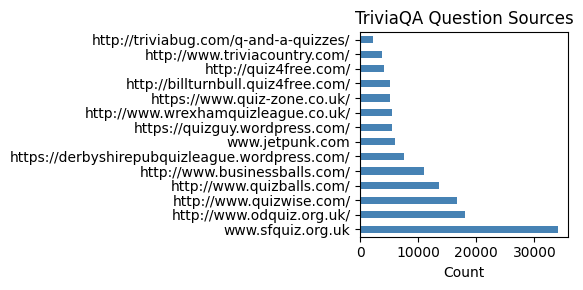

In [17]:
# Question source distribution
q_sources = [ds_train[i]['question_source'] for i in range(n_train)]
q_source_vc = pd.Series(q_sources).value_counts()
print('Question sources:')
print(q_source_vc)

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
q_source_vc.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Count')
ax.set_title('TriviaQA Question Sources')
plt.tight_layout()
plt.show()

## Inspect Examples

In [18]:
# Display a few examples using Wikipedia evidence as context
for i in range(5):
    ex = ds_train[i]
    question = ex['question']
    answer = ex['answer']['value']
    aliases = ex['answer']['aliases']

    # Pick first available Wikipedia context
    wiki_titles = ex['entity_pages']['title']
    wiki_texts = ex['entity_pages']['wiki_context']

    print(f'=== Example {i} ===')
    print(f'  Question: {question}')
    print(f'  Answer:   {answer}')
    print(f'  Aliases:  {aliases[:5]}{"..." if len(aliases) > 5 else ""}')

    if len(wiki_titles) > 0:
        print(f'  Wiki evidence ({len(wiki_titles)} docs):')
        for j in range(min(2, len(wiki_titles))):
            ctx_snippet = wiki_texts[j][:300].replace('\n', ' ')
            print(f'    [{j}] "{wiki_titles[j]}": {ctx_snippet}...')
    else:
        # Fall back to search results
        sr_titles = ex['search_results']['title']
        sr_texts = ex['search_results']['search_context']
        print(f'  Search evidence ({len(sr_titles)} docs):')
        for j in range(min(2, len(sr_titles))):
            ctx_snippet = sr_texts[j][:300].replace('\n', ' ')
            print(f'    [{j}] "{sr_titles[j]}": {ctx_snippet}...')
    print()

=== Example 0 ===
  Question: Which American-born Sinclair won the Nobel Prize for Literature in 1930?
  Answer:   Sinclair Lewis
  Aliases:  ['(Harry) Sinclair Lewis', 'Harry Sinclair Lewis', 'Lewis, (Harry) Sinclair', 'Grace Hegger', 'Sinclair Lewis']
  Search evidence (7 docs):
    [0] "The Nobel Prize in Literature 1930": The Nobel Prize in Literature 1930 The Nobel Prize in Literature 1930 Sinclair Lewis The Nobel Prize in Literature 1930 Sinclair Lewis Prize share: 1/1 The Nobel Prize in Literature 1930 was awarded to Sinclair Lewis "for his vigorous and graphic art of description and his ability to create, with wi...
    [1] "Why Don’t More Americans Win the Nobel Prize? - The New Yorker": Why Don’t More Americans Win the Nobel Prize? - The New Yorker Why Don’t More Americans Win the Nobel Prize? By    October 8, 2013 When the Nobel Prize in Literature was awarded to Sinclair Lewis, in 1930, it was the first time in the prize’s three-decade history that it had been given to an A

## Context / Answer Length Distributions

In [19]:
# Extract context + answer pairs for length analysis
# Strategy: use first Wikipedia evidence document as context, answer value as answer
tqa_ctx_lens = []
tqa_q_lens = []
tqa_ans_lens = []
tqa_wiki_doc_lens = []  # full wiki doc char lengths

for i in range(n_train):
    ex = ds_train[i]
    question = ex['question']
    answer = ex['answer']['value']

    # Pick first wiki context if available, else first search context
    wiki_texts = ex['entity_pages']['wiki_context']
    sr_texts = ex['search_results']['search_context']
    if len(wiki_texts) > 0:
        context = wiki_texts[0]
    elif len(sr_texts) > 0:
        context = sr_texts[0]
    else:
        continue

    ctx_toks = tkz(context, add_special_tokens=False).input_ids
    q_toks = tkz(question, add_special_tokens=False).input_ids
    ans_toks = tkz(answer, add_special_tokens=False).input_ids

    tqa_ctx_lens.append(len(ctx_toks))
    tqa_q_lens.append(len(q_toks))
    tqa_ans_lens.append(len(ans_toks))
    tqa_wiki_doc_lens.append(len(context))

tqa_ctx_lens = np.array(tqa_ctx_lens)
tqa_q_lens = np.array(tqa_q_lens)
tqa_ans_lens = np.array(tqa_ans_lens)

print(f'Processed {len(tqa_ctx_lens)} examples with evidence')
print('\nContext token lengths:')
print(f'  mean={tqa_ctx_lens.mean():.1f}, median={np.median(tqa_ctx_lens):.1f}, '
      f'min={tqa_ctx_lens.min()}, max={tqa_ctx_lens.max()}, std={tqa_ctx_lens.std():.1f}')
print('Question token lengths:')
print(f'  mean={tqa_q_lens.mean():.1f}, median={np.median(tqa_q_lens):.1f}, '
      f'min={tqa_q_lens.min()}, max={tqa_q_lens.max()}, std={tqa_q_lens.std():.1f}')
print('Answer token lengths:')
print(f'  mean={tqa_ans_lens.mean():.1f}, median={np.median(tqa_ans_lens):.1f}, '
      f'min={tqa_ans_lens.min()}, max={tqa_ans_lens.max()}, std={tqa_ans_lens.std():.1f}')

Token indices sequence length is longer than the specified maximum sequence length for this model (17430 > 512). Running this sequence through the model will result in indexing errors


Processed 138384 examples with evidence

Context token lengths:
  mean=6034.9, median=4271.0, min=13, max=179010, std=6338.8
Question token lengths:
  mean=17.9, median=16.0, min=5, max=253, std=9.1
Answer token lengths:
  mean=2.3, median=2.0, min=1, max=44, std=1.5


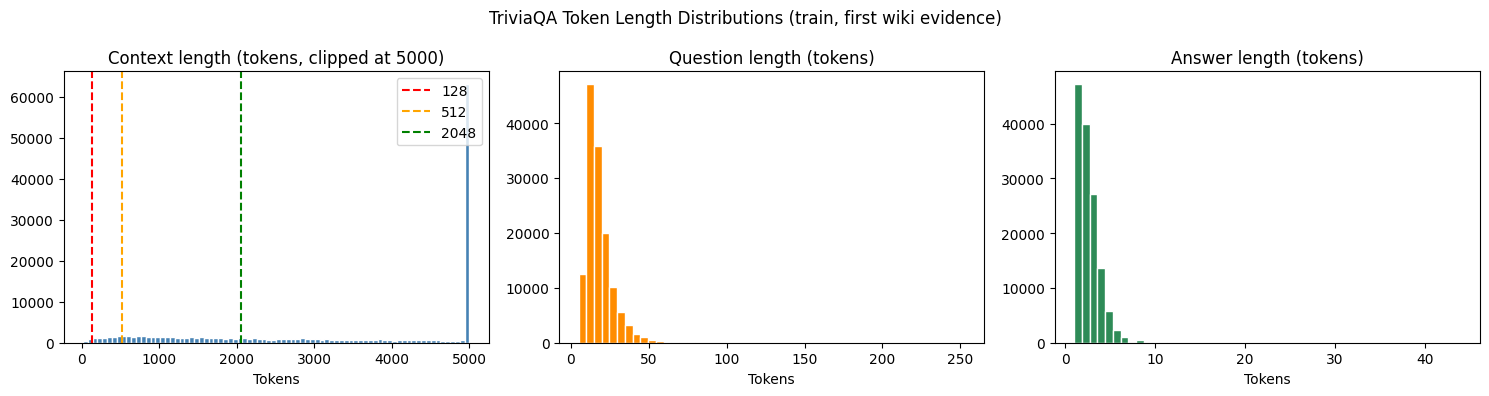

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Context lengths are very long in TriviaQA — clip for visualization
ctx_clip = np.clip(tqa_ctx_lens, 0, 5000)
axes[0].hist(ctx_clip, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Context length (tokens, clipped at 5000)')
axes[0].set_xlabel('Tokens')
axes[0].axvline(128, color='red', linestyle='--', label='128')
axes[0].axvline(512, color='orange', linestyle='--', label='512')
axes[0].axvline(2048, color='green', linestyle='--', label='2048')
axes[0].legend()

axes[1].hist(tqa_q_lens, bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Question length (tokens)')
axes[1].set_xlabel('Tokens')

axes[2].hist(tqa_ans_lens, bins=50, color='seagreen', edgecolor='white')
axes[2].set_title('Answer length (tokens)')
axes[2].set_xlabel('Tokens')

plt.suptitle('TriviaQA Token Length Distributions (train, first wiki evidence)')
plt.tight_layout()
plt.show()

In [21]:
# Chunk analysis — TriviaQA has much longer contexts than SQuAD
for inp_len in [128, 256, 384, 512]:
    chunk_content = inp_len - 2
    n_chunks = np.ceil(tqa_ctx_lens / chunk_content).astype(int)
    multi = (n_chunks > 1).sum()
    print(f'inp_len={inp_len}: need >1 chunk: {multi}/{len(tqa_ctx_lens)} ({multi/len(tqa_ctx_lens):.1%}), '
          f'max chunks: {n_chunks.max()}, mean chunks: {n_chunks.mean():.1f}')

# Percentage of contexts fitting into common max_chunks limits
print()
for max_chunks in [1, 4, 10, 20]:
    chunk_content = 128 - 2  # using inp_len=128
    n_chunks = np.ceil(tqa_ctx_lens / chunk_content).astype(int)
    fits = (n_chunks <= max_chunks).sum()
    print(f'inp_len=128, max_chunks={max_chunks}: fits {fits}/{len(tqa_ctx_lens)} ({fits/len(tqa_ctx_lens):.1%})')

inp_len=128: need >1 chunk: 137407/138384 (99.3%), max chunks: 1421, mean chunks: 48.4
inp_len=256: need >1 chunk: 135156/138384 (97.7%), max chunks: 705, mean chunks: 24.3
inp_len=384: need >1 chunk: 132391/138384 (95.7%), max chunks: 469, mean chunks: 16.3
inp_len=512: need >1 chunk: 129293/138384 (93.4%), max chunks: 351, mean chunks: 12.3

inp_len=128, max_chunks=1: fits 977/138384 (0.7%)
inp_len=128, max_chunks=4: fits 8986/138384 (6.5%)
inp_len=128, max_chunks=10: fits 26341/138384 (19.0%)
inp_len=128, max_chunks=20: fits 47893/138384 (34.6%)


## Convert to Unified QnA Format

In [ ]:
# Convert TriviaQA to unified QnA format: (context, question, answer, source)
# Use first Wikipedia evidence as context (preferred), fall back to first search result
# Answer: use the canonical answer value

rows_unified = []
for split_name in ['train', 'validation']:
    ds_split = ds_tqa[split_name]
    for i in range(len(ds_split)):
        ex = ds_split[i]
        question = ex['question']
        answer = ex['answer']['value']

        wiki_texts = ex['entity_pages']['wiki_context']
        sr_texts = ex['search_results']['search_context']
        if len(wiki_texts) > 0:
            context = wiki_texts[0]
        elif len(sr_texts) > 0:
            context = sr_texts[0]
        else:
            continue

        # Skip if context or answer is empty
        if not context.strip() or not answer.strip():
            continue

        rows_unified.append({
            'context': context,
            'question': question,
            'answer': answer,
            'source': 'triviaqa',
        })

df_unified_tqa = pd.DataFrame(rows_unified)
print(f'Unified TriviaQA rows (train + val): {len(df_unified_tqa)}')
df_unified_tqa.head()

In [ ]:
# Save unified format
unified_fpath = QNA_DATA_PATH / 'triviaqa_unified.parquet'
df_unified_tqa.to_parquet(unified_fpath, index=False)
print(f'Saved to {unified_fpath} ({len(df_unified_tqa)} rows)')